In [1]:
#################################################
# 1. Load Credentials
#################################################

import os
from dotenv import load_dotenv

load_dotenv()

DBREPO_USER = os.getenv("DBREPO_USER")
DBREPO_PASSWORD = os.getenv("DBREPO_PASSWORD")

print("Credentials loaded successfully.")

Credentials loaded successfully.


In [2]:
#################################################
# 2. Initialize DBRepo Client
#################################################

from dbrepo.RestClient import RestClient

BASE_URL = "https://test.dbrepo.tuwien.ac.at"

client = RestClient(
    BASE_URL,
    username=DBREPO_USER,
    password=DBREPO_PASSWORD
)

print("DBRepo client initialized.")

DBRepo client initialized.


In [5]:
#################################################
# 3. Configure Database and View
#################################################

DB_ID = "81d82941-cae0-4cba-b27d-1bd883dd713a"

VIEW_NAME = "vw_air_quality_features"

print("Database configured.")

print("View:", VIEW_NAME)

Database configured.
View: vw_air_quality_features


In [9]:
#################################################
# 4. Retrieve View Metadata
#################################################

views = client.get_views(DB_ID)

feature_view = None

for view in views:

    if view.name == VIEW_NAME:

        feature_view = view

        break

if feature_view is None:

    raise Exception(f"View '{VIEW_NAME}' not found.")

print("View found successfully.")

print("View Name:", feature_view.name)

print("View ID:", feature_view.id)

View found successfully.
View Name: vw_air_quality_features
View ID: d813aea7-7397-4821-9618-7922760ee604


In [10]:
#################################################
# 5. Load Data from DBRepo API
#################################################

import pandas as pd
import time
from requests.exceptions import ConnectionError

MAX_RETRIES = 5

retry_counter = 0

while retry_counter < MAX_RETRIES:

    try:

        #################################################
        # Load feature view data
        #################################################

        df_measurement = client.get_view_data(

            database_id=DB_ID,

            view_id=feature_view.id,

            page=0,

            size=1000000
        )

        #################################################
        # Retrieve table metadata
        #################################################

        tables = client.get_tables(DB_ID)

        station_table = None

        time_table = None

        for table in tables:

            if table.name == "t_station":

                station_table = table

            elif table.name == "t_time":

                time_table = table

        if station_table is None:

            raise Exception("t_station not found.")

        if time_table is None:

            raise Exception("t_time not found.")

        #################################################
        # Load station table
        #################################################

        df_station = client.get_table_data(

            database_id=DB_ID,

            table_id=station_table.id,

            page=0,

            size=1000000
        )

        #################################################
        # Load time table
        #################################################

        df_time = client.get_table_data(

            database_id=DB_ID,

            table_id=time_table.id,

            page=0,

            size=1000000
        )

        print("All datasets loaded successfully.")

        break

    except ConnectionError:

        retry_counter += 1

        print(
            f"Connection failed. Retry {retry_counter}/{MAX_RETRIES}"
        )

        time.sleep(3)

    except Exception as e:

        raise Exception(f"Unexpected API error: {e}")

if retry_counter == MAX_RETRIES:

    raise Exception("Failed to retrieve data from DBRepo API.")

print("\nMeasurement Shape:")

print(df_measurement.shape)

print("\nStation Shape:")

print(df_station.shape)

print("\nTime Shape:")

print(df_time.shape)

All datasets loaded successfully.

Measurement Shape:
(43800, 20)

Station Shape:
(5, 4)

Time Shape:
(8760, 3)


In [11]:
#################################################
# 6. Join API Datasets
#################################################

# Merge station metadata
df = pd.merge(

    df_measurement,

    df_station,

    on="station_id",

    how="left"
)

# Merge temporal metadata
df = pd.merge(

    df,

    df_time,

    on="time_id",

    how="left"
)

print("Datasets joined successfully.")

print("\nFinal Shape:")

print(df.shape)

print("\nColumns:\n")

print(df.columns.tolist())

display(df.head())

Datasets joined successfully.

Final Shape:
(43800, 25)

Columns:

['pm25', 'measurement_id', 'o3', 'humidity', 'solar_radiation', 'time_id', 'mxil', 'wind_speed', 'pressure', 'no2', 'ben', 'no', 'so2', 'temperature', 'wind_direction', 'station_id', 'rain', 'pm10', 'tol', 'co', 'station_name', 'latitude', 'longitude', 'date', 'hour']


,pm25,measurement_id,o3,humidity,solar_radiation,time_id,mxil,wind_speed,pressure,no2,...,station_id,rain,pm10,tol,co,station_name,latitude,longitude,date,hour
0,3.0,1,58.0,54.0,17.0,8737,0.40,1.13,1009.0,15.0,...,1,0.0,5.0,0.60,0.29,Estación Avenida Constitución,43.529806,-5.673428,2013-12-31,1
1,6.0,2,54.0,55.0,17.0,8738,0.60,0.48,1008.0,14.0,...,1,0.0,4.0,0.90,0.25,Estación Avenida Constitución,43.529806,-5.673428,2013-12-31,2
2,6.0,3,50.0,58.0,17.0,8739,1.88,0.10,1007.0,16.0,...,1,0.0,7.0,0.92,0.26,Estación Avenida Constitución,43.529806,-5.673428,2013-12-31,3
3,1.0,4,68.0,53.0,17.0,8740,3.20,0.75,1006.0,5.0,...,1,0.0,6.0,1.23,0.24,Estación Avenida Constitución,43.529806,-5.673428,2013-12-31,4
4,1.0,5,56.0,55.0,17.0,8741,0.63,0.78,1006.0,13.0,...,1,0.0,6.0,0.50,0.26,Estación Avenida Constitución,43.529806,-5.673428,2013-12-31,5


In [12]:
#################################################
# 7. Inspect Final Dataset
#################################################

print("Shape:")

print(df.shape)

print("\nColumns:\n")

print(df.columns.tolist())

print("\nMissing Values:\n")

print(df.isnull().sum())

Shape:
(43800, 25)

Columns:

['pm25', 'measurement_id', 'o3', 'humidity', 'solar_radiation', 'time_id', 'mxil', 'wind_speed', 'pressure', 'no2', 'ben', 'no', 'so2', 'temperature', 'wind_direction', 'station_id', 'rain', 'pm10', 'tol', 'co', 'station_name', 'latitude', 'longitude', 'date', 'hour']

Missing Values:

pm25               0
measurement_id     0
o3                 0
humidity           0
solar_radiation    0
time_id            0
mxil               0
wind_speed         0
pressure           0
no2                0
ben                0
no                 0
so2                0
temperature        0
wind_direction     0
station_id         0
rain               0
pm10               0
tol                0
co                 0
station_name       0
latitude           0
longitude          0
date               0
hour               0
dtype: int64


In [13]:
#################################################
# 8. Create Target Variable
#################################################

def air_quality(pm25):

    if pm25 < 20:

        return "Good"

    elif pm25 < 50:

        return "Moderate"

    else:

        return "Poor"

df["Air_Quality_Class"] = df["pm25"].apply(
    air_quality
)

print("Target variable created successfully.")

print("\nClass Distribution:\n")

print(
    df["Air_Quality_Class"].value_counts()
)

display(
    df[["pm25", "Air_Quality_Class"]].head()
)

Target variable created successfully.

Class Distribution:

Air_Quality_Class
Good        41523
Moderate     2176
Poor          101
Name: count, dtype: int64


,pm25,Air_Quality_Class
0,3.0,Good
1,6.0,Good
2,6.0,Good
3,1.0,Good
4,1.0,Good


In [14]:
#################################################
# 9. Feature Selection & Cleaning
#################################################

# Remove PM2.5 to prevent leakage
# Remove identifiers and non-ML attributes

features = [

    "so2",
    "no",
    "no2",
    "co",
    "pm10",
    "o3",

    "wind_direction",
    "wind_speed",

    "temperature",
    "humidity",
    "pressure",

    "solar_radiation",
    "rain",

    "ben",
    "tol",
    "mxil",

    "latitude",
    "longitude",
    "hour"
]

df_ml = df[
    features + ["Air_Quality_Class"]
].dropna()

print("ML dataset prepared successfully.")

print("\nShape:")

print(df_ml.shape)

display(df_ml.head())

ML dataset prepared successfully.

Shape:
(43800, 20)


,so2,no,no2,co,pm10,o3,wind_direction,wind_speed,temperature,humidity,pressure,solar_radiation,rain,ben,tol,mxil,latitude,longitude,hour,Air_Quality_Class
0,4.0,2.0,15.0,0.29,5.0,58.0,158.0,1.13,14.1,54.0,1009.0,17.0,0.0,0.10,0.60,0.40,43.529806,-5.673428,1,Good
1,3.0,1.0,14.0,0.25,4.0,54.0,203.0,0.48,14.1,55.0,1008.0,17.0,0.0,0.10,0.90,0.60,43.529806,-5.673428,2,Good
2,5.0,1.0,16.0,0.26,7.0,50.0,5.0,0.10,13.4,58.0,1007.0,17.0,0.0,0.10,0.92,1.88,43.529806,-5.673428,3,Good
3,4.0,1.0,5.0,0.24,6.0,68.0,181.0,0.75,15.3,53.0,1006.0,17.0,0.0,0.13,1.23,3.20,43.529806,-5.673428,4,Good
4,4.0,2.0,13.0,0.26,6.0,56.0,181.0,0.78,14.9,55.0,1006.0,17.0,0.0,0.10,0.50,0.63,43.529806,-5.673428,5,Good


In [15]:
#################################################
# 10. Define Features and Target
#################################################

X = df_ml.drop(
    "Air_Quality_Class",
    axis=1
)

y = df_ml["Air_Quality_Class"]

print("Features shape:")

print(X.shape)

print("\nTarget shape:")

print(y.shape)

Features shape:
(43800, 19)

Target shape:
(43800,)


In [16]:
#################################################
# 11. Train / Validation / Test Split
#################################################

from sklearn.model_selection import train_test_split

# 70% training
# 15% validation
# 15% testing

X_train, X_temp, y_train, y_temp = train_test_split(

    X,

    y,

    test_size=0.30,

    random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(

    X_temp,

    y_temp,

    test_size=0.50,

    random_state=42
)

print("Training Shape:")

print(X_train.shape)

print("\nValidation Shape:")

print(X_val.shape)

print("\nTesting Shape:")

print(X_test.shape)

Training Shape:
(30660, 19)

Validation Shape:
(6570, 19)

Testing Shape:
(6570, 19)


In [17]:
#################################################
# 12. Feature Scaling
#################################################

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_val_scaled = scaler.transform(X_val)

X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed.")

print("\nScaled Training Shape:")

print(X_train_scaled.shape)

print("\nScaled Validation Shape:")

print(X_val_scaled.shape)

print("\nScaled Testing Shape:")

print(X_test_scaled.shape)

Feature scaling completed.

Scaled Training Shape:
(30660, 19)

Scaled Validation Shape:
(6570, 19)

Scaled Testing Shape:
(6570, 19)


In [18]:
#################################################
# 13. Train Machine Learning Models
#################################################

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Initialize models

model_logistic = LogisticRegression(
    max_iter=10000
)

model_tree = DecisionTreeClassifier()

model_forest = RandomForestClassifier()

# Train models

model_logistic.fit(
    X_train_scaled,
    y_train
)

model_tree.fit(
    X_train_scaled,
    y_train
)

model_forest.fit(
    X_train_scaled,
    y_train
)

print("All models trained successfully.")

All models trained successfully.


In [19]:
#################################################
# 14. Generate Predictions
#################################################

pred_logistic = model_logistic.predict(
    X_test_scaled
)

pred_tree = model_tree.predict(
    X_test_scaled
)

pred_forest = model_forest.predict(
    X_test_scaled
)

print("Predictions generated successfully.")

Predictions generated successfully.


In [20]:
#################################################
# 15. Evaluate Model Accuracy
#################################################

from sklearn.metrics import accuracy_score

acc_logistic = accuracy_score(
    y_test,
    pred_logistic
)

acc_tree = accuracy_score(
    y_test,
    pred_tree
)

acc_forest = accuracy_score(
    y_test,
    pred_forest
)

print("Logistic Regression Accuracy:")

print(acc_logistic)

print("\nDecision Tree Accuracy:")

print(acc_tree)

print("\nRandom Forest Accuracy:")

print(acc_forest)

Logistic Regression Accuracy:
0.9505327245053272

Decision Tree Accuracy:
0.9407914764079147

Random Forest Accuracy:
0.9579908675799087


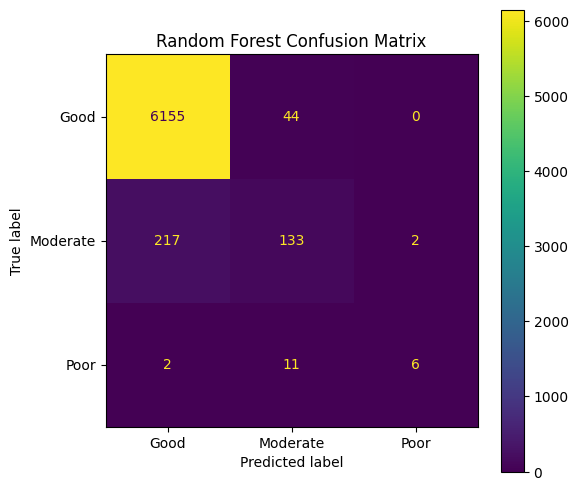

In [21]:
#################################################
# 16. Confusion Matrix
#################################################

import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(
    y_test,
    pred_forest
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=model_forest.classes_
)

fig, ax = plt.subplots(figsize=(6, 6))

disp.plot(ax=ax)

plt.title("Random Forest Confusion Matrix")

plt.savefig(
    "../outputs/outp_confusion_matrix_api_v1.png",
    bbox_inches="tight"
)

plt.show()

In [22]:
#################################################
# 17. Classification Report
#################################################

from sklearn.metrics import classification_report

report = classification_report(
    y_test,
    pred_forest
)

print("Random Forest Classification Report:\n")

print(report)

Random Forest Classification Report:

              precision    recall  f1-score   support

        Good       0.97      0.99      0.98      6199
    Moderate       0.71      0.38      0.49       352
        Poor       0.75      0.32      0.44        19

    accuracy                           0.96      6570
   macro avg       0.81      0.56      0.64      6570
weighted avg       0.95      0.96      0.95      6570



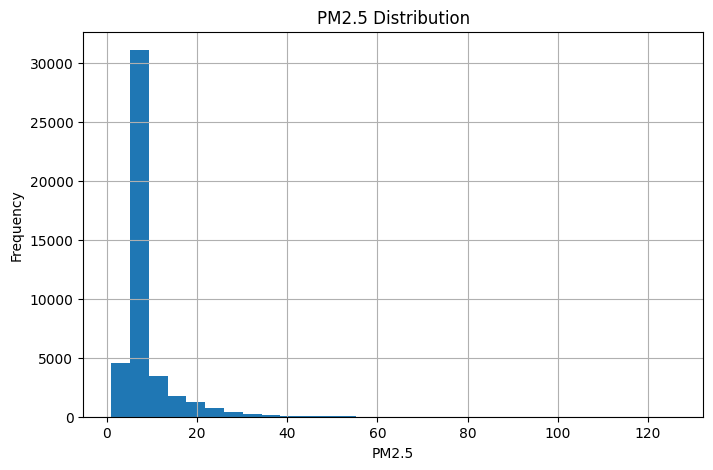

In [23]:
#################################################
# 18. PM2.5 Distribution Plot
#################################################

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

df["pm25"].hist(bins=30)

plt.title("PM2.5 Distribution")

plt.xlabel("PM2.5")

plt.ylabel("Frequency")

plt.savefig(
    "../outputs/outp_pm25_histogram_api_v1.png",
    bbox_inches="tight"
)

plt.show()

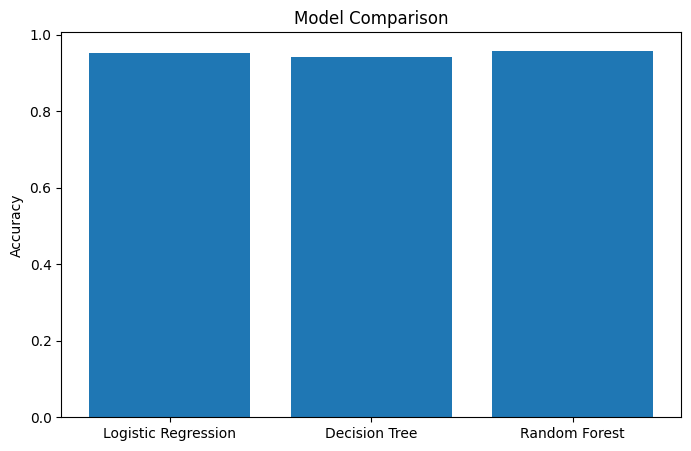

In [24]:
#################################################
# 19. Model Comparison Plot
#################################################

models = [

    "Logistic Regression",

    "Decision Tree",

    "Random Forest"
]

scores = [

    acc_logistic,

    acc_tree,

    acc_forest
]

plt.figure(figsize=(8, 5))

plt.bar(models, scores)

plt.ylabel("Accuracy")

plt.title("Model Comparison")

plt.savefig(
    "../outputs/outp_model_comparison_api_v1.png",
    bbox_inches="tight"
)

plt.show()

In [25]:
#################################################
# 20. Save Best Model
#################################################

import joblib

MODEL_PATH = "../models/model_randomforest_api_v1.pkl"

joblib.dump(
    model_forest,
    MODEL_PATH
)

print("Model saved successfully.")

print("\nLocation:")

print(MODEL_PATH)

Model saved successfully.

Location:
../models/model_randomforest_api_v1.pkl


In [26]:
#################################################
# 21. Verify API Reimplementation
#################################################

print("API-based experiment completed successfully.")

print("\nData Source:")

print("DBRepo REST API")

print("\nPrimary View Used:")

print(VIEW_NAME)

print("\nAdditional API Tables:")

print("- t_station")
print("- t_time")

print("\nNo local CSV files were used.")

print("\nAll joins were reconstructed")
print("through pandas after API retrieval.")

print("\nResults are reproducible through")
print("the DBRepo REST API workflow.")

API-based experiment completed successfully.

Data Source:
DBRepo REST API

Primary View Used:
vw_air_quality_features

Additional API Tables:
- t_station
- t_time

No local CSV files were used.

All joins were reconstructed
through pandas after API retrieval.

Results are reproducible through
the DBRepo REST API workflow.
